# Домашнее задание 4

## Работа с пропусками в Loan Prediction Dataset


# 1. Загрузка данных

Считаем датасет из файла `loan_prediction_dataset.csv` и посмотрим первые строки.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("loan_prediction_dataset.csv")

df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [2]:
print("Размер датасета:", df.shape)

Размер датасета: (614, 13)



Метод `info()` показывает количество строк, названия столбцов, число непустых значений и типы данных.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


Метод `describe()` показывает основные статистики числовых признаков: количество наблюдений, среднее, стандартное отклонение, минимум, квартили и максимум.

In [4]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


# 2. Таблица пропусков

Для каждого столбца посчитаем:
- абсолютное число пропусков;
- процент пропусков от общего числа строк.

In [5]:
missing_table = pd.DataFrame({
    "Количество пропусков": df.isna().sum(),
    "Процент пропусков": (df.isna().mean() * 100).round(2)
})

missing_table

,Количество пропусков,Процент пропусков
Loan_ID,0,0.00
Gender,13,2.12
Married,3,0.49
Dependents,15,2.44
Education,0,0.00
Self_Employed,32,5.21
ApplicantIncome,0,0.00
CoapplicantIncome,0,0.00
LoanAmount,22,3.58
Loan_Amount_Term,14,2.28


# 3. Матрица пропусков

В матрице каждая строка соответствует объекту датасета, а каждый столбец — признаку.

Светлые и тёмные участки позволяют увидеть, где именно находятся пропущенные значения.

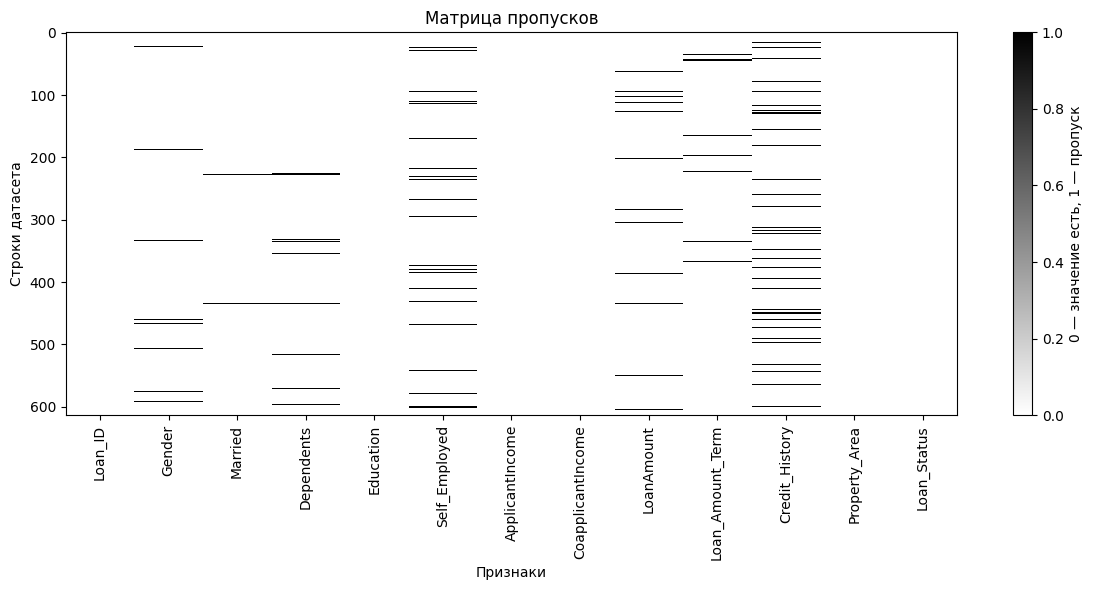

In [6]:
plt.figure(figsize=(12, 6))

plt.imshow(
    df.isna(),
    aspect="auto",
    interpolation="nearest",
    cmap="gray_r"
)

plt.title("Матрица пропусков")
plt.xlabel("Признаки")
plt.ylabel("Строки датасета")
plt.xticks(range(len(df.columns)), df.columns, rotation=90)

plt.colorbar(label="0 — значение есть, 1 — пропуск")
plt.tight_layout()
plt.show()

# 5. Тепловая карта пропусков

Для второй визуализации покажем процент пропусков в каждом столбце в виде тепловой карты.

C:\Users\spide\AppData\Local\Temp\ipykernel_16120\3469321023.py:24: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


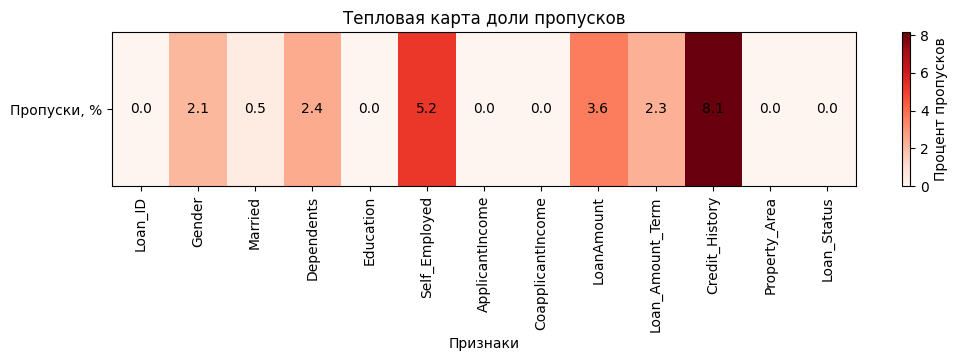

In [7]:
missing_percent = df.isna().mean() * 100

plt.figure(figsize=(12, 2))

plt.imshow(
    [missing_percent.values],
    aspect="auto",
    cmap="Reds"
)

plt.title("Тепловая карта доли пропусков")
plt.xlabel("Признаки")
plt.xticks(
    range(len(df.columns)),
    df.columns,
    rotation=90
)
plt.yticks([0], ["Пропуски, %"])

for i, value in enumerate(missing_percent):
    plt.text(i, 0, f"{value:.1f}", ha="center", va="center")

plt.colorbar(label="Процент пропусков")
plt.tight_layout()
plt.show()


Пропуски распределены по нескольким признакам, но полностью или почти полностью пустых столбцов нет.

Больше всего пропущенных значений находится в `Credit_History` — около 8% строк. Далее идут `Self_Employed` — около 5% и `LoanAmount` — около 4%.

По матрице не видно больших сплошных областей пропусков: пропущенные значения встречаются в разных строках. 

Поскольку доли пропусков сравнительно небольшие, удалять все строки с пропусками нецелесообразно: это приведёт к потере данных. Поэтому далее пропуски будут заполнены подходящими значениями.

# 5. Числовые и категориальные признаки с пропусками

Сначала определим столбцы, в которых вообще есть пропуски, а затем разделим их по типам данных.

In [8]:
columns_with_missing = df.columns[df.isna().any()]

numeric_missing = df[columns_with_missing].select_dtypes(include="number").columns.tolist()
categorical_missing = df[columns_with_missing].select_dtypes(exclude="number").columns.tolist()

print("Числовые признаки с пропусками:")
print(numeric_missing)

print("\nКатегориальные признаки с пропусками:")
print(categorical_missing)

Числовые признаки с пропусками:
['LoanAmount', 'Loan_Amount_Term', 'Credit_History']

Категориальные признаки с пропусками:
['Gender', 'Married', 'Dependents', 'Self_Employed']


По типу данных `Credit_History` относится к числовым столбцам, потому что значения представлены числами `0` и `1`.

Однако по смыслу это бинарный категориальный признак: значение обозначает наличие или отсутствие положительной кредитной истории. Поэтому при заполнении его логичнее обрабатывать как категориальный признак и использовать моду.

## 5.1 Заполнение пропусков

Используем следующие методы:

- `LoanAmount` — медиана, размер кредита является числовым признаком
- `Loan_Amount_Term` — медиана, поскольку это числовой признак,
- `Gender`, `Married`, `Dependents`, `Self_Employed` — мода, т.к. это категориальные признаки
- `Credit_History` — мода (см. выше)

Сначала создадим копию исходного датасета, чтобы можно было сравнить данные до и после обработки.

In [9]:
df_filled = df.copy()

numeric_for_median = [
    "LoanAmount",
    "Loan_Amount_Term"
]

categorical_for_mode = [
    "Gender",
    "Married",
    "Dependents",
    "Self_Employed",
    "Credit_History"
]

for column in numeric_for_median:
    df_filled[column] = df_filled[column].fillna(
        df_filled[column].median()
    )

for column in categorical_for_mode:
    df_filled[column] = df_filled[column].fillna(
        df_filled[column].mode()[0]
    )

## 5.2. Проверка заполнения пропусков

Снова посчитаем количество пропусков по каждому столбцу.

In [10]:
df_filled.isna().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [11]:
print(
    "Общее количество пропусков после заполнения:",
    df_filled.isna().sum().sum()
)

Общее количество пропусков после заполнения: 0


После заполнения общее количество пропущенных значений должно быть равно **0**.

## 5.3 Сравнение статистик до и после заполнения

Сравним основные статистики числовых признаков, в которых изначально были пропуски.

In [12]:
columns_for_comparison = [
    "LoanAmount",
    "Loan_Amount_Term",
    "Credit_History"
]

stats_before = (
    df[columns_for_comparison]
    .describe()
    .T[["count", "mean", "std", "50%"]]
)

stats_after = (
    df_filled[columns_for_comparison]
    .describe()
    .T[["count", "mean", "std", "50%"]]
)

stats_before = stats_before.add_suffix("_до")
stats_after = stats_after.add_suffix("_после")

statistics_comparison = stats_before.join(stats_after)

statistics_comparison

,count_до,mean_до,std_до,50%_до,count_после,mean_после,std_после,50%_после
LoanAmount,592.0,146.412162,85.587325,128.0,614.0,145.752443,84.107233,128.0
Loan_Amount_Term,600.0,342.000000,65.120410,360.0,614.0,342.410423,64.428629,360.0
Credit_History,564.0,0.842199,0.364878,1.0,614.0,0.855049,0.352339,1.0


Для категориальных признаков посмотрим наиболее частые значения до заполнения и после него.

In [13]:
for column in categorical_for_mode:
    print(column)
    print("Мода до заполнения:", df[column].mode()[0])
    print("Мода после заполнения:", df_filled[column].mode()[0])
    print("Количество значений после заполнения:", df_filled[column].count())
    print()

Gender
Мода до заполнения: Male
Мода после заполнения: Male
Количество значений после заполнения: 614

Married
Мода до заполнения: Yes
Мода после заполнения: Yes
Количество значений после заполнения: 614

Dependents
Мода до заполнения: 0
Мода после заполнения: 0
Количество значений после заполнения: 614

Self_Employed
Мода до заполнения: No
Мода после заполнения: No
Количество значений после заполнения: 614

Credit_History
Мода до заполнения: 1.0
Мода после заполнения: 1.0
Количество значений после заполнения: 614



После заполнения значение `count` у обработанных признаков становится равным общему количеству строк датасета.

При заполнении числовых признаков медианой сама медиана обычно не меняется, а среднее и стандартное отклонение могут немного измениться. Это происходит потому, что в распределение добавляются значения, равные медиане.

У категориальных признаков после заполнения увеличивается частота наиболее распространённой категории, поскольку именно модой были заменены пропуски.

Изменения статистик получаются относительно небольшими, так как доля пропусков в исходном датасете невелика.